# Standalone R3 + R6 Load-only Evaluation
Run only this notebook. No training or earlier notebook cells required.

**Instructions (caveman):**
1) Open and run cells in order.
2) Make sure `physionet.org/files/qtdb/1.0.0` and `physionet.org/files/ludb/1.0.1/data` exist.
3) Do NOT run any other notebook cells.

In [ ]:
%pip install -q wfdb scipy scikit-learn torch matplotlib pandas

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks, resample_poly
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import wfdb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

REPO_ROOT = Path.cwd()
QTDB_DIR = REPO_ROOT / "physionet.org/files/qtdb/1.0.0"
LUDB_DIR = REPO_ROOT / "physionet.org/files/ludb/1.0.1/data"
assert QTDB_DIR.exists(), f"No QTDB data here: {QTDB_DIR}"
assert LUDB_DIR.exists(), f"No LUDB data here: {LUDB_DIR}"

PRE = 120
R5_POST = 320
R5_BEAT_LENGTH = PRE + R5_POST
BATCH_SIZE = 64

MODEL_LOAD_PATH_R3 = "best_ml2_rpeak_guided_focal_unweighted.pth"
MODEL_LOAD_PATH_R6_QTDB = "best_ml2_r6_time_qtdb.pth"
MODEL_LOAD_PATH_R6_LUDB = "best_ml2_r6_time_ludb10.pth"
NORMALIZATION_LOAD_PATH = "best_ml2_rpeak_guided_normalization.npz"
for p in [MODEL_LOAD_PATH_R3, MODEL_LOAD_PATH_R6_QTDB, MODEL_LOAD_PATH_R6_LUDB, NORMALIZATION_LOAD_PATH]:
    assert Path(p).exists(), f"Missing file: {p}"

def generate_labels(ecg, ann):
    labels = np.zeros(len(ecg), dtype=np.int64)
    start, wave_kind = None, None
    for sample, symbol in zip(ann.sample, ann.symbol):
        if symbol == "(":
            start, wave_kind = sample, None
        elif symbol == "p":
            wave_kind = 1
        elif symbol == "N":
            wave_kind = 2
        elif symbol == "t":
            wave_kind = 3
        elif symbol == ")" and start is not None and wave_kind is not None:
            labels[start:sample + 1] = wave_kind
            start, wave_kind = None, None
    return labels

def to_pt_labels(labels):
    out = labels.copy()
    out[out == 2] = 0
    out[out == 3] = 2
    return out

def pan_tompkins_r_peaks(ecg, fs, lowcut=5.0, highcut=18.0):
    nyquist = fs / 2
    sos = butter(3, [lowcut / nyquist, highcut / nyquist], btype="bandpass", output="sos")
    bandpassed = sosfiltfilt(sos, ecg)
    derivative = np.convolve(bandpassed, np.array([-1, -2, 0, 2, 1]) * fs / 8, mode="same")
    integrated = np.convolve(derivative ** 2, np.ones(max(1, round(0.150 * fs))) / max(1, round(0.150 * fs)), mode="same")
    candidates, _ = find_peaks(integrated, distance=max(1, round(0.20 * fs)))
    boot = candidates[candidates < min(len(ecg), round(2 * fs))]
    boot = boot if len(boot) else candidates
    spki = np.percentile(integrated[boot], 90) if len(boot) else 0.0
    npki = np.percentile(integrated[boot], 25) if len(boot) else 0.0
    accepted = []
    for peak in candidates:
        threshold = npki + 0.25 * (spki - npki)
        if integrated[peak] >= threshold:
            accepted.append(peak)
            spki = 0.125 * integrated[peak] + 0.875 * spki
        else:
            npki = 0.125 * integrated[peak] + 0.875 * npki
    search = round(0.10 * fs)
    refined = []
    for peak in accepted:
        left, right = max(0, peak - search), min(len(ecg), peak + search + 1)
        refined.append(left + np.argmax(ecg[left:right]))
    return np.unique(np.asarray(refined, dtype=int))

def create_r_centered_beats(ecg, labels, r_peaks, pre=PRE, post=R5_POST):
    X, Y, kept_r = [], [], []
    for r in r_peaks:
        left, right = r - pre, r + post
        if left < 0 or right > len(ecg):
            continue
        X.append(ecg[left:right])
        Y.append(labels[left:right])
        kept_r.append(r)
    return np.asarray(X, dtype=np.float32), np.asarray(Y, dtype=np.int64), np.asarray(kept_r, dtype=int)

# Build QTDB R5-format beats and LUDB R5-format beats (no training)
def build_qtdb_r5_beats():
    records = sorted({path.stem for path in QTDB_DIR.glob("*.dat")})
    X_parts, Y_parts, record_ids = [], [], []
    for record_name in records:
        path = QTDB_DIR / record_name
        try:
            record = wfdb.rdrecord(str(path))
            ecg = record.p_signal[:, 0].astype(np.float32)
            labels = to_pt_labels(generate_labels(ecg, wfdb.rdann(str(path), "pu0")))
            r_peaks = pan_tompkins_r_peaks(ecg, float(record.fs))
            X, Y, _ = create_r_centered_beats(ecg, labels, r_peaks, pre=PRE, post=R5_POST)
            if not len(X):
                continue
            X_parts.append(X); Y_parts.append(Y); record_ids.extend([record_name] * len(X))
        except Exception as error:
            print(f"Skipped {record_name}: {error}")
    X_r5 = np.concatenate(X_parts)
    Y_r5 = np.concatenate(Y_parts)
    record_ids = np.asarray(record_ids)
    return X_r5, Y_r5, record_ids

# ludb_labels_at_250 must be defined before build_ludb_r5_beats
def ludb_labels_at_250(annotation, original_length):
    labels = np.zeros(round(original_length / 2), dtype=np.int64)
    start, kind = None, None
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol == '(':
            start, kind = sample, None
        elif symbol == 'p':
            kind = 1
        elif symbol == 'N':
            kind = 2
        elif symbol == 't':
            kind = 3
        elif symbol == ')' and start is not None and kind is not None:
            left, right = round(start / 2), round(sample / 2)
            labels[left:right + 1] = kind
            start, kind = None, None
    return labels

def build_ludb_r5_beats():
    X_parts, Y_parts, record_ids = [], [], []
    for header in sorted(LUDB_DIR.glob("*.hea")):
        record_name = header.stem
        path = str(header.with_suffix(""))
        record = wfdb.rdrecord(path)
        lead = record.sig_name.index("ii")
        signal = resample_poly(record.p_signal[:, lead].astype(np.float32), up=1, down=2)
        annotation = wfdb.rdann(path, "ii")
        labels = ludb_labels_at_250(annotation, len(record.p_signal))
        size = min(len(signal), len(labels))
        signal, labels = signal[:size], labels[:size]
        labels = to_pt_labels(labels)
        r_peaks = pan_tompkins_r_peaks(signal, 250.0)
        X, Y, _ = create_r_centered_beats(signal, labels, r_peaks, pre=PRE, post=R5_POST)
        if len(X):
            X_parts.append(X); Y_parts.append(Y); record_ids.extend([record_name] * len(X))
    X_ludb_r5 = np.concatenate(X_parts)
    Y_ludb_r5 = np.concatenate(Y_parts)
    record_ids = np.asarray(record_ids)
    return X_ludb_r5, Y_ludb_r5, record_ids

# Build data (no training). This may take time but is required for evaluation.
X_r5, Y_r5, r5_record_ids = build_qtdb_r5_beats()
r5_train_records, r5_val_records = train_test_split(np.unique(r5_record_ids), test_size=0.20, random_state=7, shuffle=True)
r5_train_mask = np.isin(r5_record_ids, r5_train_records)
r5_val_mask = np.isin(r5_record_ids, r5_val_records)
r5_mean, r5_std = X_r5[r5_train_mask].mean(), X_r5[r5_train_mask].std()

X_ludb_r5, Y_ludb_r5, ludb_ids_r5 = build_ludb_r5_beats()

# Normalization load for simple R3 model scaling (R3 uses R1 normalization)
norm = np.load(NORMALIZATION_LOAD_PATH)
train_mean, train_std = norm['train_mean'], norm['train_std']

# Prepare R3 val loader using R5-derived windows scaled by R1 normalization
X_val_r3 = (X_r5[r5_val_mask] - train_mean) / train_std
Y_val_r3 = Y_r5[r5_val_mask]
val_loader_r3 = DataLoader(TensorDataset(torch.tensor(X_val_r3).unsqueeze(1), torch.tensor(Y_val_r3)), batch_size=BATCH_SIZE, shuffle=False)

# Model classes
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
        )
    def forward(self, x):
        return self.features(x)

class BiLSTMBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)
    def forward(self, x):
        return self.lstm(x)[0]

class RPeakGuidedML2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.bilstm = BiLSTMBlock()
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x = self.bilstm(x)
        return self.classifier(self.dropout(x))

class RPeakTimeML2(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.bilstm = nn.LSTM(64, 128, num_layers=1, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        return self.classifier(self.dropout(self.bilstm(x)[0]))

def with_time_channel(signals):
    time = (np.arange(signals.shape[1], dtype=np.float32) - PRE) / R5_POST
    return np.stack([signals.astype(np.float32), np.broadcast_to(time, signals.shape)], axis=1).copy()

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load R3 model and evaluate on QTDB R5-derived validation set
model_r3 = RPeakGuidedML2().to(device)
model_r3.load_state_dict(torch.load(MODEL_LOAD_PATH_R3, map_location=device))
model_r3.eval()
print(f"Loaded R3 model from {MODEL_LOAD_PATH_R3}")

Device: mps
Loaded R3 model from best_ml2_rpeak_guided_focal_unweighted.pth


              precision    recall  f1-score   support

  Background     0.9397    0.9485    0.9441   6619252
      P Wave     0.8971    0.8314    0.8630   1176872
      T Wave     0.8784    0.8878    0.8831   2232796

    accuracy                         0.9212  10028920
   macro avg     0.9050    0.8892    0.8967  10028920
weighted avg     0.9210    0.9212    0.9210  10028920

R3 QTDB hold-out P F1: 0.8630 | T F1: 0.8831 | Macro F1: 0.8967


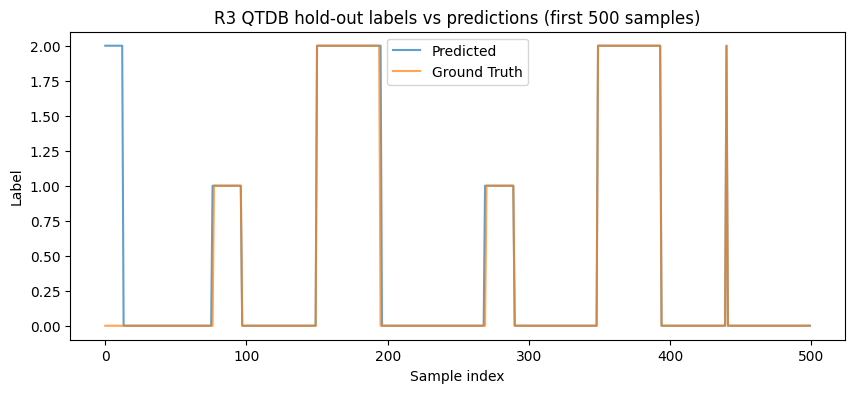

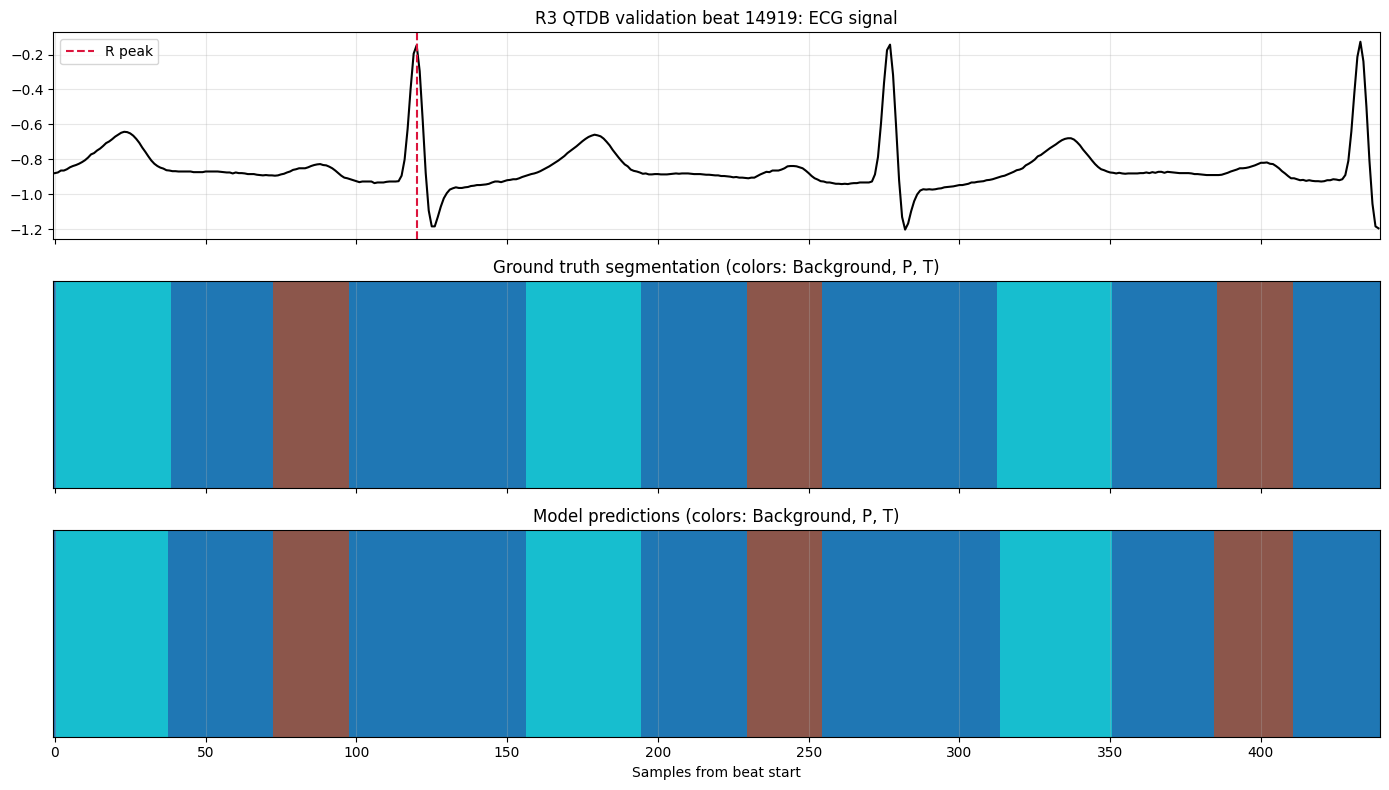

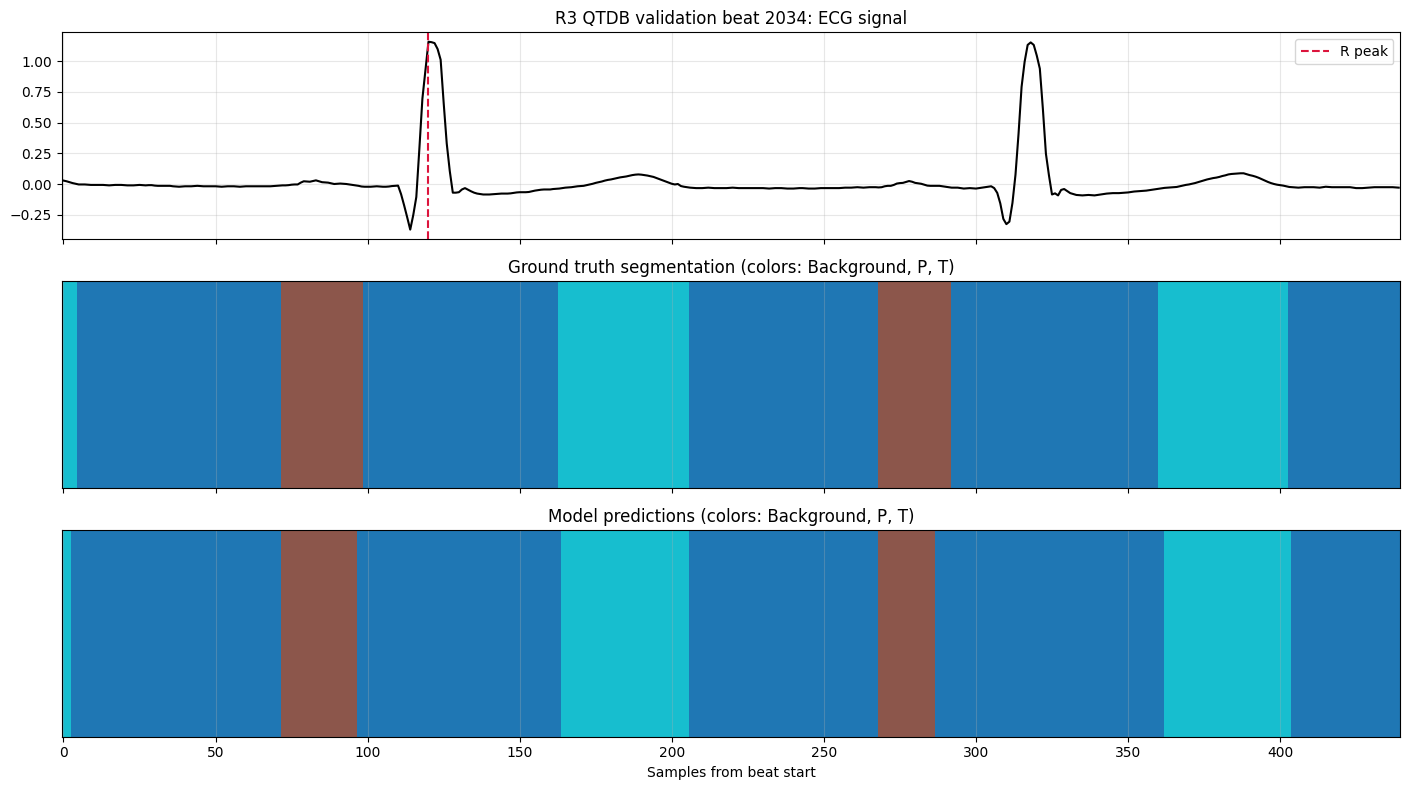

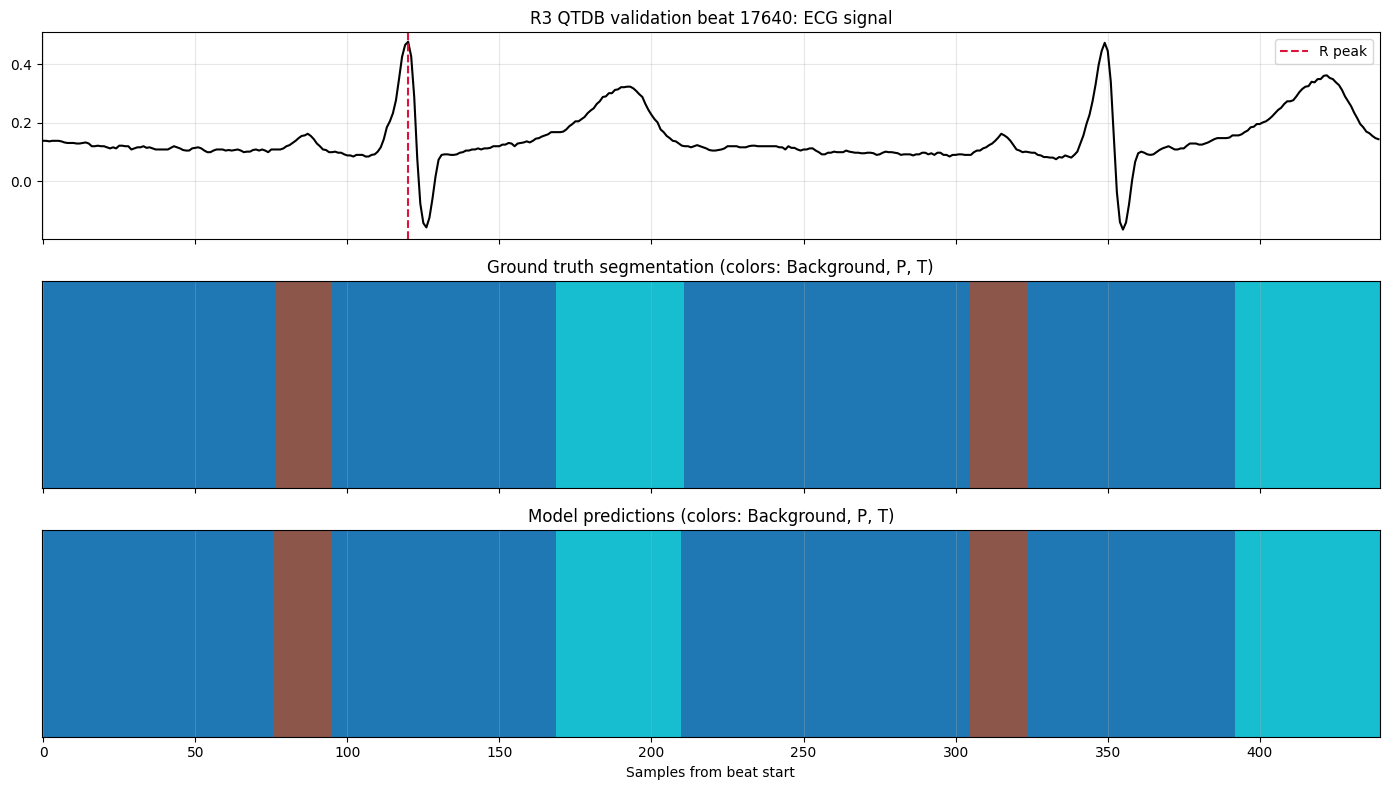

In [3]:
# R3 evaluation on QTDB hold-out validation set
all_predictions_r3, all_labels_r3 = [], []
with torch.no_grad():
    for batch_x, batch_labels in val_loader_r3:
        predicted = model_r3(batch_x.to(device)).argmax(dim=2).cpu().numpy()
        all_predictions_r3.append(predicted)
        all_labels_r3.append(batch_labels.numpy())
all_predictions_r3 = np.concatenate(all_predictions_r3)
all_labels_r3 = np.concatenate(all_labels_r3)

print(classification_report(all_labels_r3.ravel(), all_predictions_r3.ravel(), labels=[0, 1, 2], target_names=["Background", "P Wave", "T Wave"], digits=4, zero_division=0))
p_f1_r3, t_f3_r3 = f1_score(all_labels_r3.ravel(), all_predictions_r3.ravel(), labels=[1, 2], average=None, zero_division=0)
macro_f1_r3 = f1_score(all_labels_r3.ravel(), all_predictions_r3.ravel(), labels=[0, 1, 2], average="macro", zero_division=0)
print(f"R3 QTDB hold-out P F1: {p_f1_r3:.4f} | T F1: {t_f3_r3:.4f} | Macro F1: {macro_f1_r3:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(all_predictions_r3.ravel()[:500], label="Predicted", alpha=0.7)
plt.plot(all_labels_r3.ravel()[:500], label="Ground Truth", alpha=0.7)
plt.legend()
plt.title("R3 QTDB hold-out labels vs predictions (first 500 samples)")
plt.xlabel("Sample index")
plt.ylabel("Label")
plt.show()

rng = np.random.default_rng(42)
for idx in rng.choice(len(val_loader_r3.dataset), size=min(3, len(val_loader_r3.dataset)), replace=False):
    signal = val_loader_r3.dataset[idx][0].squeeze().numpy()
    truth = val_loader_r3.dataset[idx][1].numpy()
    pred = all_predictions_r3[idx]
    x = np.arange(R5_BEAT_LENGTH)
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(x, signal, color="black")
    axes[0].axvline(PRE, color="crimson", ls="--", label="R peak")
    axes[0].legend()
    axes[0].set_title(f"R3 QTDB validation beat {idx}: ECG signal")
    axes[1].imshow([truth], aspect="auto", cmap="tab10")
    axes[1].set_yticks([])
    axes[1].set_title("Ground truth segmentation (colors: Background, P, T)")
    axes[2].imshow([pred], aspect="auto", cmap="tab10")
    axes[2].set_yticks([])
    axes[2].set_title("Model predictions (colors: Background, P, T)")
    for ax in axes:
        ax.grid(alpha=0.3)
    axes[2].set_xlabel("Samples from beat start")
    plt.tight_layout()
    plt.show()

Loaded R6 QTDB model from best_ml2_r6_time_qtdb.pth
R6 QTDB hold-out P F1: 0.8814 | T F1: 0.9036 | Macro F1: 0.9122
              precision    recall  f1-score   support

  Background     0.9456    0.9579    0.9517   6619252
      P Wave     0.8868    0.8762    0.8814   1176872
      T Wave     0.9187    0.8890    0.9036   2232796

    accuracy                         0.9330  10028920
   macro avg     0.9170    0.9077    0.9122  10028920
weighted avg     0.9327    0.9330    0.9327  10028920

Loaded R6 LUDB-adapted model from best_ml2_r6_time_ludb10.pth
R6 LUDB untouched test P F1: 0.8107 | T F1: 0.8022 | Macro F1: 0.8451
              precision    recall  f1-score   support

  Background     0.9381    0.9073    0.9224    527523
      P Wave     0.7696    0.8564    0.8107     75566
      T Wave     0.7758    0.8305    0.8022    125111

    accuracy                         0.8888    728200
   macro avg     0.8278    0.8647    0.8451    728200
weighted avg     0.8927    0.8888    0.8902  

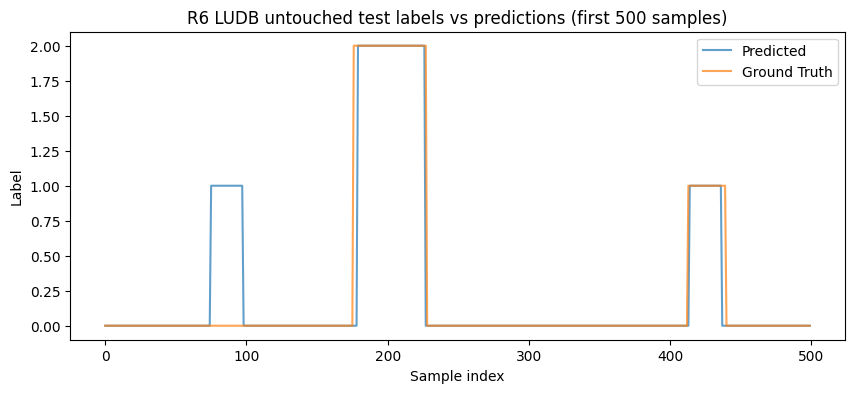

In [4]:
# R6 evaluation: QTDB hold-out and untouched LUDB test
R6_ADAPT_FRACTION = 0.10
r6_test_records = train_test_split(np.unique(ludb_ids_r5), test_size=1 - R6_ADAPT_FRACTION, random_state=17, shuffle=True)[1]
r6_qtdb_val_x = with_time_channel((X_r5[~r5_train_mask] - r5_mean) / r5_std)
r6_qtdb_val_loader = DataLoader(TensorDataset(torch.tensor(r6_qtdb_val_x), torch.tensor(Y_r5[~r5_train_mask])), batch_size=BATCH_SIZE, shuffle=False)

r6_qtdb_model = RPeakTimeML2().to(device)
r6_qtdb_model.load_state_dict(torch.load(MODEL_LOAD_PATH_R6_QTDB, map_location=device))
r6_qtdb_model.eval()
print(f"Loaded R6 QTDB model from {MODEL_LOAD_PATH_R6_QTDB}")

r6_qtdb_predictions, r6_qtdb_labels = [], []
with torch.no_grad():
    for batch_x, batch_labels in r6_qtdb_val_loader:
        r6_qtdb_predictions.append(r6_qtdb_model(batch_x.to(device)).argmax(dim=2).cpu().numpy())
        r6_qtdb_labels.append(batch_labels.numpy())
r6_qtdb_predictions = np.concatenate(r6_qtdb_predictions)
r6_qtdb_labels = np.concatenate(r6_qtdb_labels)
r6_qtdb_p, r6_qtdb_t = f1_score(r6_qtdb_labels.ravel(), r6_qtdb_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r6_qtdb_macro = f1_score(r6_qtdb_labels.ravel(), r6_qtdb_predictions.ravel(), labels=[0, 1, 2], average="macro", zero_division=0)
print(f"R6 QTDB hold-out P F1: {r6_qtdb_p:.4f} | T F1: {r6_qtdb_t:.4f} | Macro F1: {r6_qtdb_macro:.4f}")
print(classification_report(r6_qtdb_labels.ravel(), r6_qtdb_predictions.ravel(), labels=[0, 1, 2], target_names=["Background", "P Wave", "T Wave"], digits=4, zero_division=0))

r6_test_mask = np.isin(ludb_ids_r5, r6_test_records)
r6_ludb_test_x = with_time_channel((X_ludb_r5[r6_test_mask] - r5_mean) / r5_std)
r6_ludb_test_y = Y_ludb_r5[r6_test_mask]
r6_ludb_model = RPeakTimeML2().to(device)
r6_ludb_model.load_state_dict(torch.load(MODEL_LOAD_PATH_R6_LUDB, map_location=device))
r6_ludb_model.eval()
print(f"Loaded R6 LUDB-adapted model from {MODEL_LOAD_PATH_R6_LUDB}")

r6_ludb_predictions = []
with torch.no_grad():
    for start in range(0, len(r6_ludb_test_x), BATCH_SIZE):
        batch = torch.tensor(r6_ludb_test_x[start:start + BATCH_SIZE]).to(device)
        r6_ludb_predictions.append(r6_ludb_model(batch).argmax(dim=2).cpu().numpy())
r6_ludb_predictions = np.concatenate(r6_ludb_predictions)
r6_ludb_p, r6_ludb_t = f1_score(r6_ludb_test_y.ravel(), r6_ludb_predictions.ravel(), labels=[1, 2], average=None, zero_division=0)
r6_ludb_macro = f1_score(r6_ludb_test_y.ravel(), r6_ludb_predictions.ravel(), labels=[0, 1, 2], average="macro", zero_division=0)
print(f"R6 LUDB untouched test P F1: {r6_ludb_p:.4f} | T F1: {r6_ludb_t:.4f} | Macro F1: {r6_ludb_macro:.4f}")
print(classification_report(r6_ludb_test_y.ravel(), r6_ludb_predictions.ravel(), labels=[0, 1, 2], target_names=["Background", "P Wave", "T Wave"], digits=4, zero_division=0))

plt.figure(figsize=(10, 4))
plt.plot(r6_ludb_predictions.ravel()[:500], label="Predicted", alpha=0.7)
plt.plot(r6_ludb_test_y.ravel()[:500], label="Ground Truth", alpha=0.7)
plt.legend()
plt.title("R6 LUDB untouched test labels vs predictions (first 500 samples)")
plt.xlabel("Sample index")
plt.ylabel("Label")
plt.show()